## Current Profiled Metrics

- "Temperature.gpu"
    - Core GPU temperature. in degrees C.

- "Power.draw"
    - The last measured power draw for the entire board, in watts. On Ampere or newer devices, returns average power draw over 1 sec. On older devices, returns instantaneous power draw. Only available if power management is supported. This reading is accurate to within +/- 5 watts.

- "power.limit"
    - The software power limit in watts. Set by software like nvidia-smi. On Kepler devices Power Limit can be adjusted using [-pl | --power-limit=] switches

- "enforced.power.limit" or "gpu.power.current_limit"
    - The power management algorithm's power ceiling, in watts. Total board power draw is manipulated by the power management algorithm such that it stays under this value. This value is the minimum of various power limiters.

- "pstate"
    - The current performance state for the GPU. States range from P0 (maximum performance) to P12 (minimum performance).
    Section about clocks_event_reasons properties
    --
    HW Thermal Slowdown: temperature being too high
    HW Power Brake Slowdown: External Power Brake Assertion is triggered (e.g. by the system power supply)
    * Power draw is too high and Fast Trigger protection is reducing the clocks
    * May be also reported during PState or clock change
    * This behavior may be removed in a later release

- "clocks_throttle_reasons.active"
    - Bitmask of active clock event reasons. See nvml.h for more details.

- "clocks_throttle_reasons.gpu_idle"
    - Nothing is running on the GPU and the clocks are dropping to Idle state. This limiter may be removed in a later release.

- "clocks_throttle_reasons.sw_power_cap"
    - SW Power Scaling algorithm is reducing the clocks below requested clocks because the GPU is consuming too much power. E.g. SW power cap limit can be changed with nvidia-smi --power-limit=

- "memory.used"
    - Total memory allocated by active contexts.

- "memory.total"
    - Total installed GPU memory.

- utilization.memory
    - Percent of time over the past sample period during which global (device) memory was being read or written. The sample period may be between 1 second and 1/6 second depending on the product.

- utilization.gpu
    - Percent of time over the past sample period during which one or more kernels was executing on the GPU. The sample period may be between 1 second and 1/6 second depending on the product.

- "clocks.current.sm" or "clocks.sm"
    - Current frequency of SM (Streaming Multiprocessor) clock.

- "clocks.current.memory" or "clocks.mem"
    - Current frequency of memory clock.



## Graphs and Findings


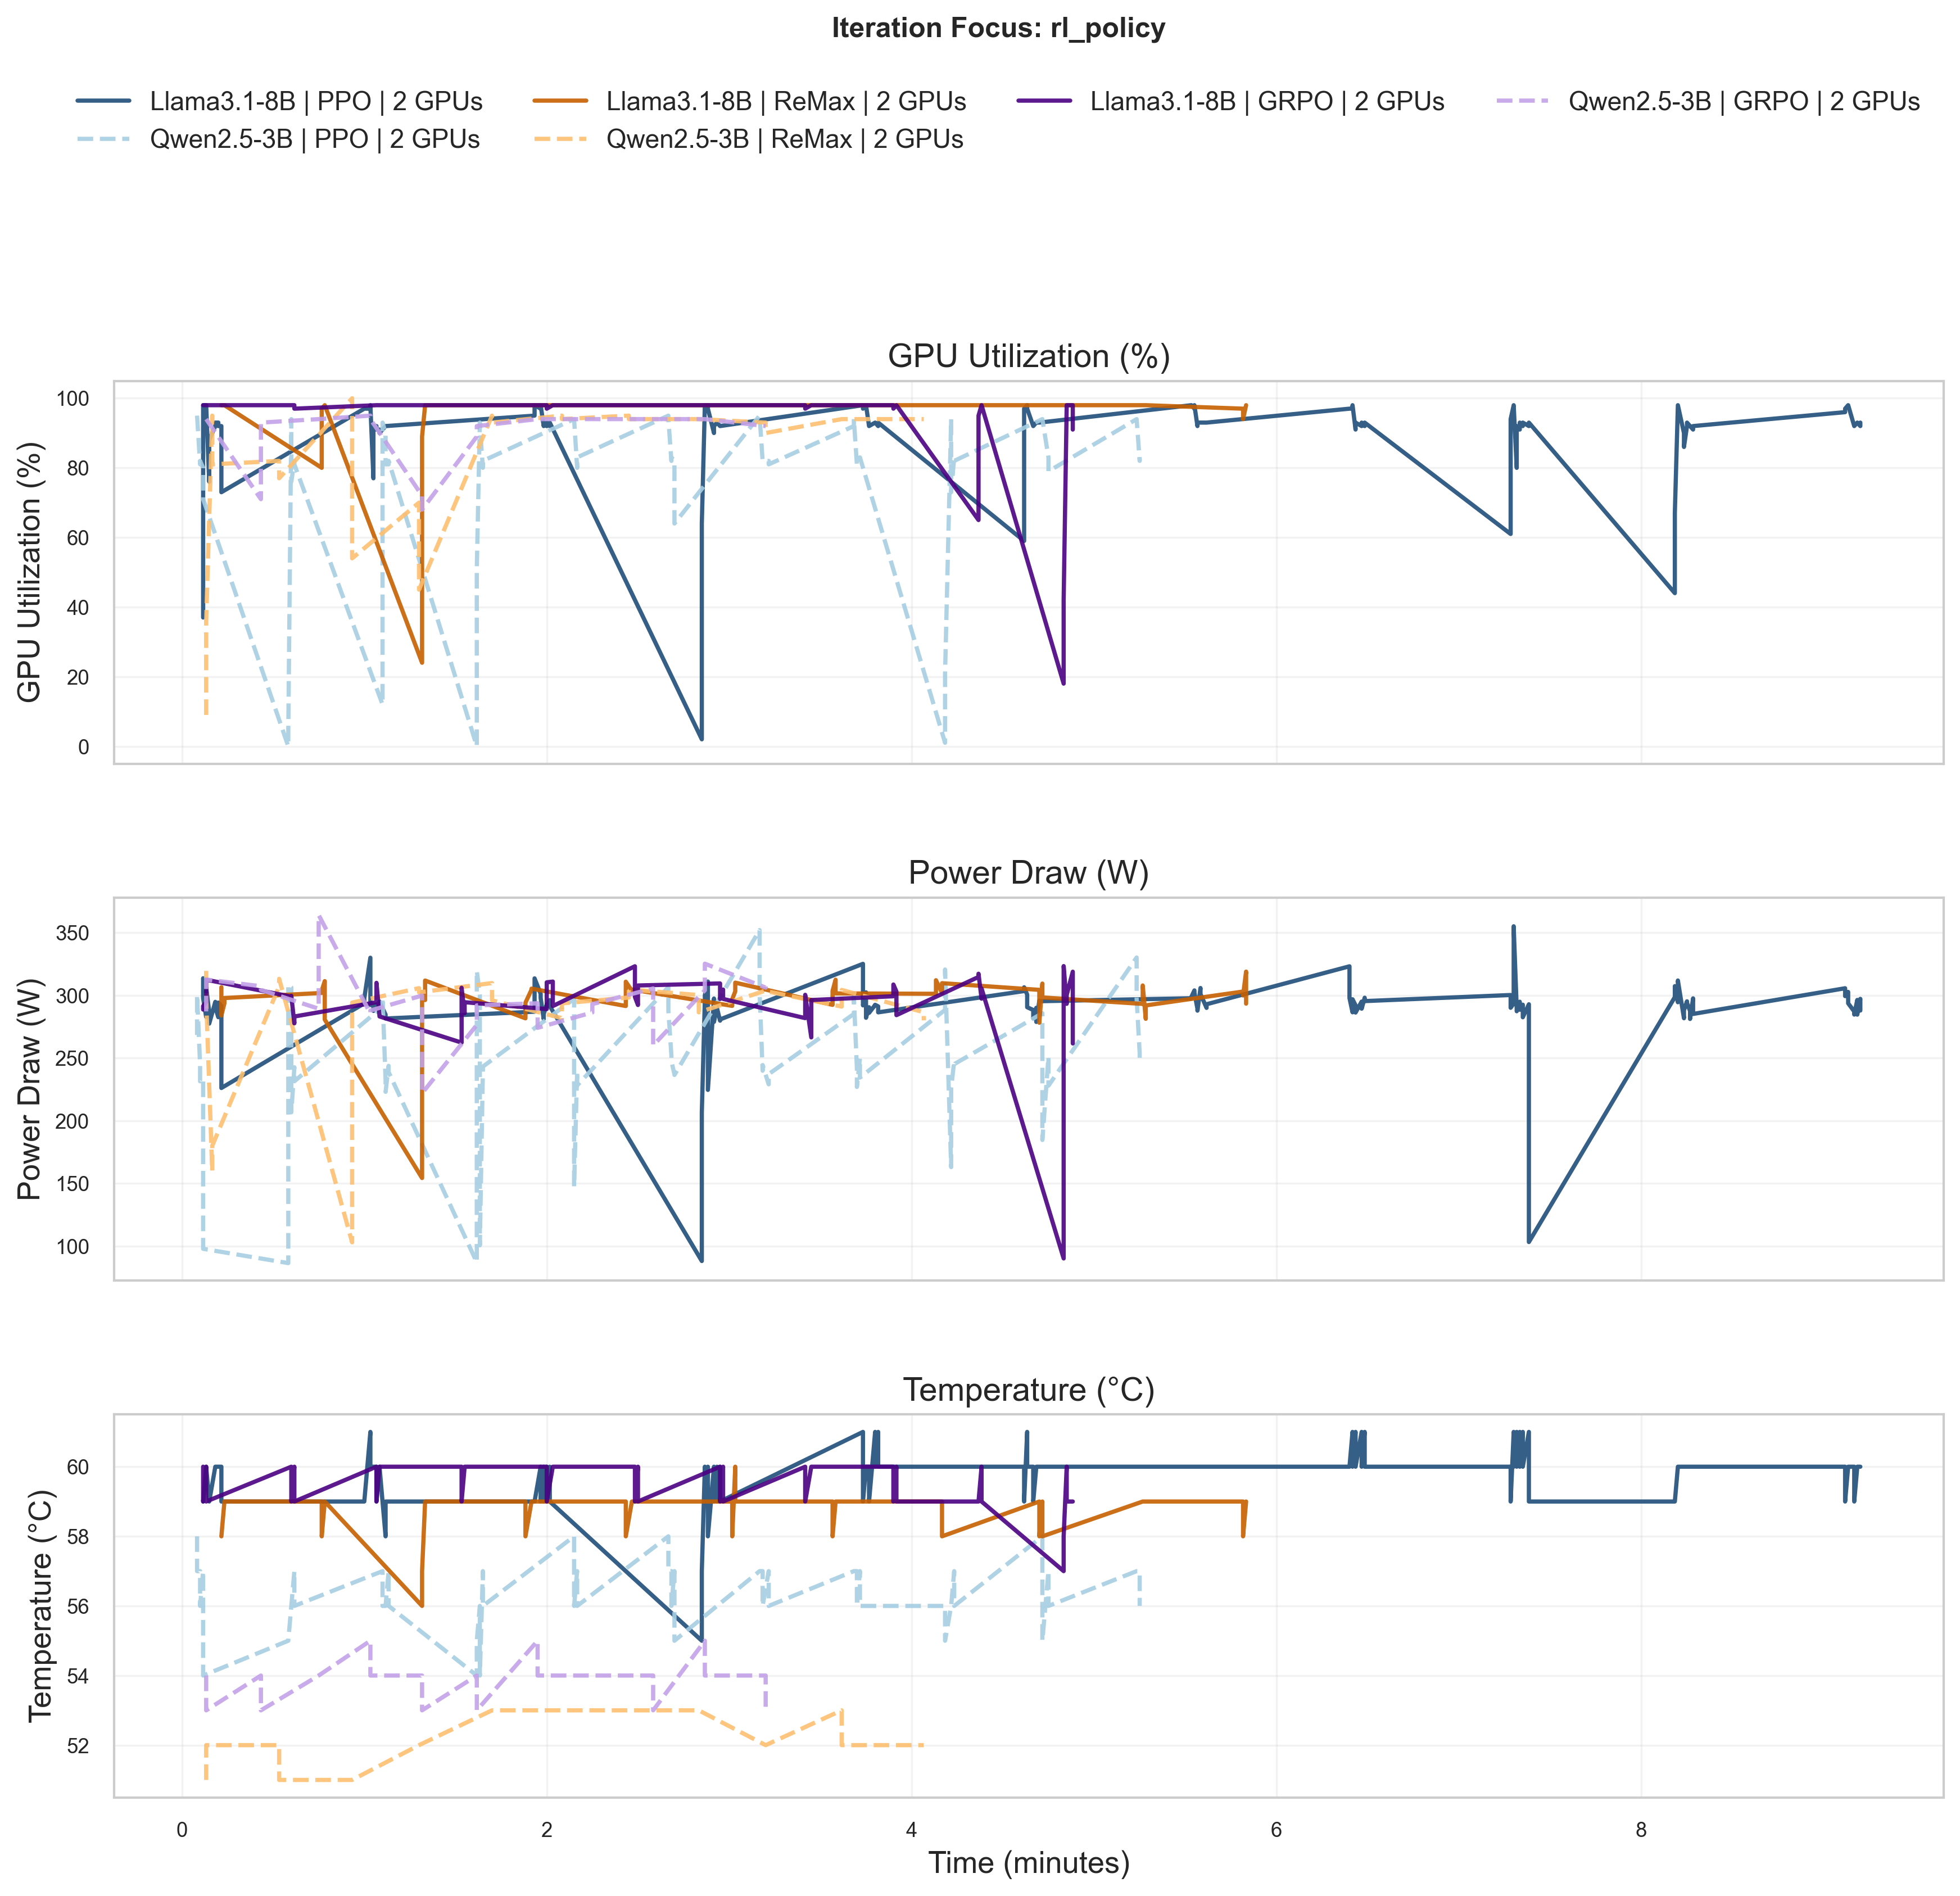
---


## Current Analysis Findings (Running List)

#### Learning
- ReMax learns faster than PPO (achieves higher reward on same number of tokens)

#### Temperature
- PPO sustains higher steady-state temperature than ReMax, but PPO benefits more from scaling from 1 -> 2 GPUs (reduces thermal load more)
- Rollout is consistently the least thermally demanding phase. 

#### Scaling
- per-GPU throughout drops when scaling from 1 -> 2 GPUs
- scaling 1 -> 2 GPUS reduces the energy footprint of training, but not rollout
- ReMax scaling from 1-> 2 GPUs shows a correlation collapse in RL policy for power-temp, power-mem, temp-mem (less compute dominated after scaling)

#### Energy Footprint/Power/Util
- Training occupies highest power-draw across all runs, followed by RL policy
- Rollout has a wide GPU utilization spread (bursty GPU use) and low power draw
- Rollout is time-dominant but is relatively power-light
- ReMax training correlations are weaker than PPO training correlations across util-mem, temp-mem, power-mem
- ReMax 2 GPUs has power peak; ReMax 1 GPU has utilization spike

## Research Reading Findings and Next Steps

- Verl's system is best suited for highly distributed, multi-node, large models
    - Novel distributed architecture mixing single and multi-controller architecture
    - **Next: test on larger cluster, with larger models**
- Several forms of parallelism are supported (Data, Tensor, and Pipeline)
    - ZeRO: memory-optimized solution for DP training. In normal DP, each GPU has a full copy of parameters, gradients, optimizer states. 
        - ZeRO-1 shards optimizer states
        - ZeRO-2 shards optimizer states + gradients
        - ZeRO-3 shards optimizer states + gradients + parameters
    - 3D: Combine across DP, TP, PP
        - Megatron-LM
    - FSDP: fully shared data parallelism (similar to ZeRO-3) -> This is what is currently used
    - **Next: test various parallelism strategies (3D sound interesting so maybe Megatron-LM) on more nodes and monitor idle time**
- VeRL is designed to flexibly support several RLHF algorithms:
    - GRPO, RLOO, REINFORCE++, GPG, OPO
    - GRPO: critic-free, samples multiple responses per prompt and updates the policy using rewards
    - ReMax: requires an additional generation pass for variance reduction and eliminates the critic model in the dataflow.
    - **Next: other policies worth testing?**
- VeRL optimizes transition times between training and generation
    - **Next: examine transition latencies, E2E if distributed workload is of primary interest**
- Optimizes mapping of RLHF dataflow and models to given devices. 
    - There are usually 3-4 LLMs involved: actor, critic, reference policy, reward model. 
    - VeRL implements algorithm that allocates models to devices with a smart auto-mapping, simulation-based method
    - Colocation (placing rollout and training models on the same GPU) shown to be most efficient on small clusters with fewer nodes
    - Algorithm is run before starting RLHF dataflow to determine ideal mapping
    - **Next: analyze the configs/inspect the decisions made on model placements across experiments. Investigate whether there is co-location**
- VeRL original research used following configs:
    - Dahoas/ful-hh-rlhf dataset
    - 1 epoch
    - llama models from 7B+ parameters
    - 8 update iterations per epoch
    - 1024 input/output response length
    - 1024 batch size of input prompts to actor output
    - Throughout (tokens/s) is the primary performance metric
    - **Next: use Dahoas/ful-hh-rlhf dataset?**

  
